In [1]:
##### Creates maps of agricultural production (national & sub-national)

import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
import matplotlib.patches as mpatches

In [2]:
##### Load data

# Get the current working directory
cd = os.path.dirname(os.getcwd())

# Import sub-national data

sub_capital = pd.read_csv(f"{cd}/Data/Clean/Intensities/subnational_capital_intensity.csv")
sub_labor = pd.read_csv(f"{cd}/Data/Clean/Intensities/subnational_labor_intensity.csv")

sub_geo_capital = gpd.read_file(f"{cd}/Data/Clean/Geographies/subnational_capital.shp")
sub_geo_labor = gpd.read_file(f"{cd}/Data/Clean/Geographies/subnational_labor.shp")

# Import country data

country_intensities = pd.read_csv(f"{cd}/Data/Clean/Intensities/country_intensities.csv")
country_shp = gpd.read_file("/Users/carinamanitius/Documents/Data/Admin_Boundaries/gadm_410-levels.gpkg", layer='ADM_0')

country_codes = pd.read_csv(f"{cd}/Data/Correspondence_tables/country_names.csv", encoding="cp1252")

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/map_production"

In [3]:
### Data prep

# align crs

crs = "ESRI:54042"

sub_geo_capital = sub_geo_capital.to_crs(crs)
sub_geo_labor = sub_geo_labor.to_crs(crs)
country_shp = country_shp.to_crs(crs)

# prep country shp 
country_shp = country_shp.merge(country_codes, left_on='GID_0', right_on='SHP_code', how='inner')

# join data to shape
sub_geo_capital = sub_geo_capital.merge(sub_capital, on='PROJ_ID', how='inner')
sub_geo_labor = sub_geo_labor.merge(sub_labor, on='PROJ_ID', how='inner')

country_shp = country_shp.merge(country_intensities, on='ISO3', how='outer')

# change units
sub_geo_capital['total_production_mUSD'] = sub_geo_capital['total_production_USD'] / 1e6
sub_geo_labor['total_production_mUSD'] = sub_geo_labor['total_production_USD'] / 1e6
country_shp['total_production_mUSD'] = country_shp['ag_production_thousand_USD_2020'] / 1e3

In [4]:
##### Create groupings for data

# capital 
cap_bins = [0, 5, 15, 50, 200, float('inf')]
cap_labels = ['0-5', '5-15', '15-50', '50-200', '200+']

sub_geo_capital['bucket'] = pd.cut(
    sub_geo_capital['total_production_mUSD'],
    bins=cap_bins,
    labels=cap_labels
)

# labor 
lab_bins = [0, 5, 15, 50, 200, float('inf')]
lab_labels = ['0-5', '5-15', '15-50', '50-200', '200+']

sub_geo_labor['bucket'] = pd.cut(
    sub_geo_labor['total_production_mUSD'],
    bins=lab_bins,
    labels=lab_labels
)

In [5]:
sub_geo_labor['total_production_mUSD'].quantile([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

0.1      2.212709
0.2      4.742411
0.3      8.575370
0.4     14.610647
0.5     23.941976
0.6     39.580842
0.7     65.346074
0.8    122.691478
0.9    315.582355
Name: total_production_mUSD, dtype: float64

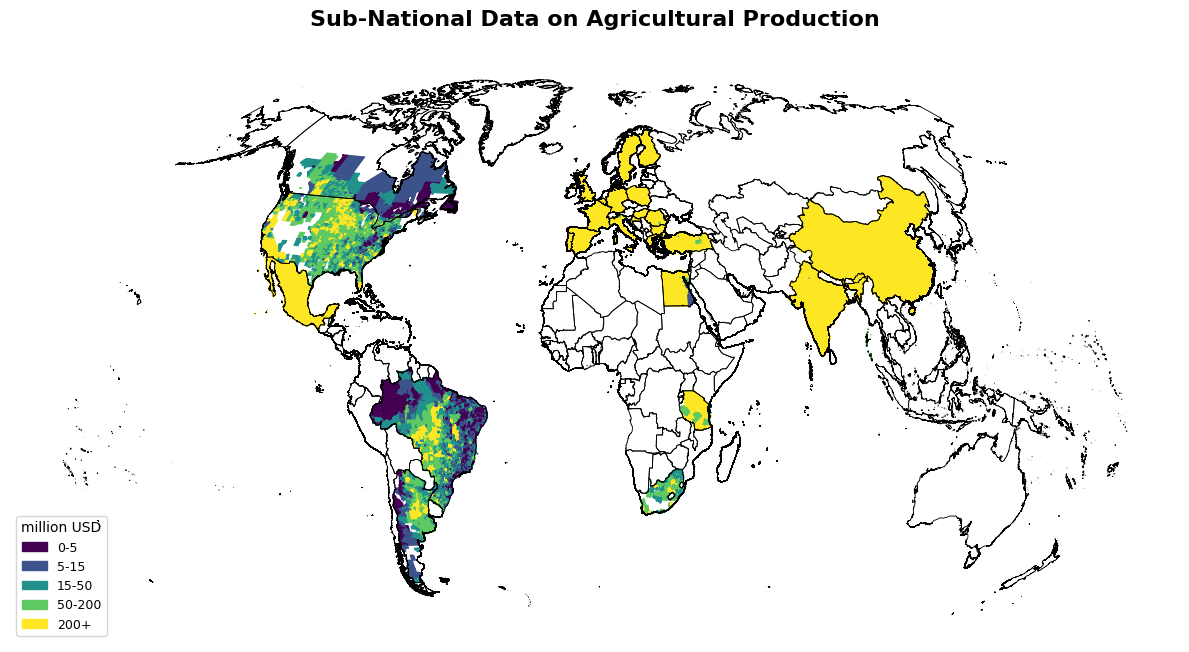

In [6]:
##### Plot sub-national production (capital)

colors = plt.cm.viridis([i / (len(cap_labels) - 1) for i in range(len(cap_labels))])

### Plot
fig, ax = plt.subplots(figsize=(12,8))

# Plot buckets
sub_geo_capital.plot(
    column='bucket',
    cmap='viridis',
    edgecolor='face',
    ax=ax,
    legend=False,  # manual legend below
    zorder=2
)

# Add country boundaries
country_shp.boundary.plot(
    ax=ax,
    color='black',
    linewidth=0.6,
    zorder=10
)

# Manual discrete legend
patches = [mpatches.Patch(color=colors[i], label=cap_labels[i]) for i in range(len(cap_labels))]
ax.legend(
    handles=patches,
    title="million USD",
    loc='lower left',
    frameon=True,
    fontsize=9,
    title_fontsize=10
)

# Aesthetics
ax.set_axis_off()  
ax.set_title("Sub-National Data on Agricultural Production", fontsize=16, weight='bold', pad=20)
plt.tight_layout()

plt.show()

fig.savefig(f"{fd}/subnational_production_capital.png", dpi=300, bbox_inches='tight')

In [ ]:
##### Plot sub-national production (labor)

colors = plt.cm.viridis([i / (len(lab_labels) - 1) for i in range(len(lab_labels))])

### Plot
fig, ax = plt.subplots(figsize=(12,8))

# Plot buckets
sub_geo_labor.plot(
    column='bucket',
    cmap='viridis',
    edgecolor='face',
    ax=ax,
    legend=False,  # manual legend below
    zorder=2
)

# Add country boundaries
country_shp.boundary.plot(
    ax=ax,
    color='black',
    linewidth=0.6,
    zorder=10
)

# Manual discrete legend
patches = [mpatches.Patch(color=colors[i], label=lab_labels[i]) for i in range(len(lab_labels))]
ax.legend(
    handles=patches,
    title="million USD",
    loc='lower left',
    frameon=True,
    fontsize=9,
    title_fontsize=10
)

# Aesthetics
ax.set_axis_off()  
ax.set_title("Sub-National Data on Agricultural Production", fontsize=16, weight='bold', pad=20)
plt.tight_layout()

plt.show()

fig.savefig(f"{fd}/subnational_production_labor.png", dpi=300, bbox_inches='tight')

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x105f05670>>
Traceback (most recent call last):
  File "/Users/carinamanitius/Library/Python/3.9/lib/python/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


In [8]:
##### Creat groupings for country data

# capital 
bins = [0, 500, 5000, 20000, 50000, float('inf')]
labels = ['0-500', '500-5,000', '5,000-20,000', '20,000-50,000', '50,000+']

country_shp['bucket'] = pd.cut(
    country_shp['total_production_mUSD'],
    bins=bins,
    labels=labels
)

In [9]:
country_shp['total_production_mUSD'].quantile([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

0.1       87.985749
0.2      290.335012
0.3      951.731257
0.4     1947.930289
0.5     3620.963000
0.6     5343.711600
0.7     8974.476942
0.8    17702.437997
0.9    43385.365600
Name: total_production_mUSD, dtype: float64

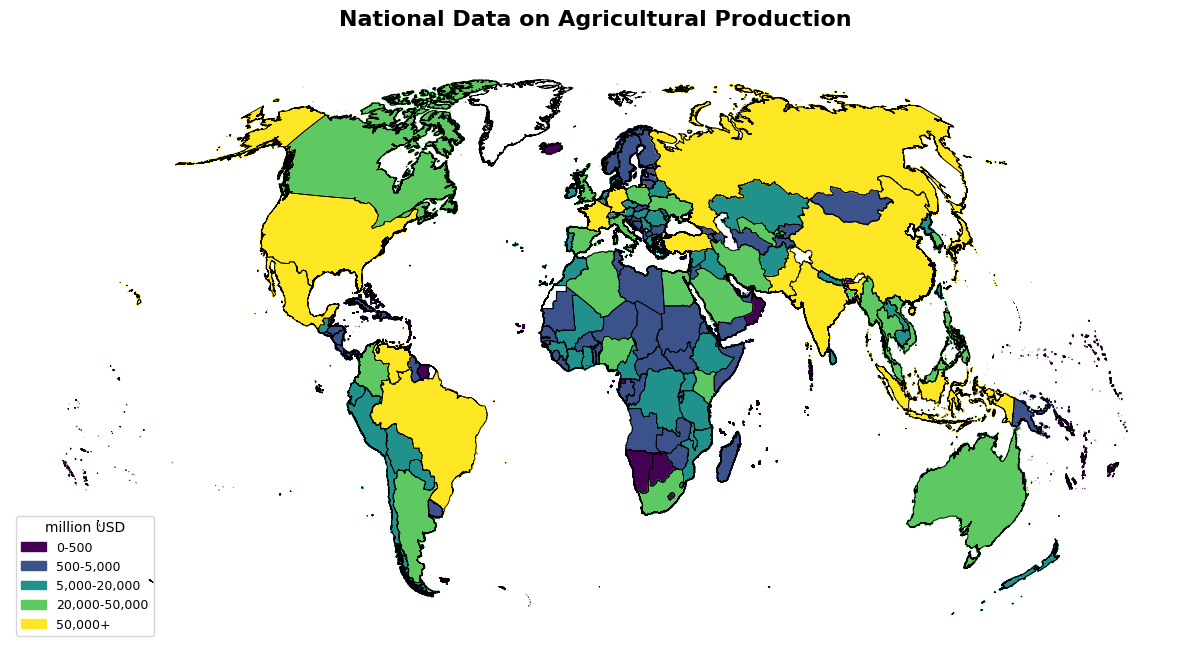

In [10]:
##### Plot national production

colors = plt.cm.viridis([i / (len(labels) - 1) for i in range(len(labels))])

### Plot
fig, ax = plt.subplots(figsize=(12,8))

# Plot buckets
country_shp.plot(
    column='bucket',
    cmap='viridis',
    edgecolor='face',
    ax=ax,
    legend=False,  # manual legend below
    zorder=2
)

# Add country boundaries
country_shp.boundary.plot(
    ax=ax,
    color='black',
    linewidth=0.6,
    zorder=10
)

# Manual discrete legend
patches = [mpatches.Patch(color=colors[i], label=labels[i]) for i in range(len(labels))]
ax.legend(
    handles=patches,
    title="million USD",
    loc='lower left',
    frameon=True,
    fontsize=9,
    title_fontsize=10
)

# Aesthetics
ax.set_axis_off()  
ax.set_title("National Data on Agricultural Production", fontsize=16, weight='bold', pad=20)
plt.tight_layout()

plt.show()

fig.savefig(f"{fd}/national_production.png", dpi=300, bbox_inches='tight')